# NASA Earth Asteroids Prediction

## Importing the Libraries

In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option('display.max_columns', None)

## Importing Data

### DataFrame 1

In [73]:
df1 = pd.read_csv(r'C:\prerit\Projects\NASA-Asteroid-Hazard-Prediction\data\asteroid_close_approaches_2015_2035.csv')


### DataFrame 2

In [74]:
df2 = pd.read_csv(r'C:\prerit\Projects\NASA-Asteroid-Hazard-Prediction\data\near_earth_asteroids_2025.csv')

C:\Users\Prerit\AppData\Local\Temp\ipykernel_19944\3868240768.py:1: DtypeWarning: Columns (0: name) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(r'C:\prerit\Projects\NASA-Asteroid-Hazard-Prediction\data\near_earth_asteroids_2025.csv')


In [75]:
print('shape of df1 : ', df1.shape)
print('shape of df2 :', df2.shape)

shape of df1 :  (27430, 13)
shape of df2 : (41281, 29)


In [76]:
df1.head()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False


distance_au = distance of asteroid from earth in Astronomical Unit

1 astronomical unit (AU) = 149,597,870.7 kilometres (KM)

Solar System Examples:

Earth: 1 AU from the Sun.

Jupiter: ~5.2 AU from the Sun.

Pluto: ~39.5 AU from the Sun

Voyager 1: Over 171 AU (as of Feb 2026), making it the farthest human-made object.

Beyond the Solar System: The distance to the nearest star, Proxima Centauri, is about 268,000 AU (4.2 light-years).

Conversion: One light-year is approximately 63,241 AU.

In [77]:
df2.head()

,spkid,full_name,pdes,name,pha,H,diameter_km,diameter_m,diameter_is_estimated,size_category,albedo,rot_per,class,e,a,i,q,ad,per,per_y,moid_au,moid_km,moid_lunar_distances,n,condition_code,first_obs,last_obs,data_arc,data_arc_years
0,20000433,433 Eros (A898 PA),433,Eros,False,10.39,16.84000,16840.0,False,Large (>1 km) — City killer+,0.250,5.270,AMO,0.2228,1.458,10.83,1.133,1.78,643.0,1.76,0.1480,22140485.0,57.60,0.5598,0.0,1893-10-29,2021-05-13,46582.0,127.53
1,20000719,719 Albert (A911 TB),719,Albert,False,15.59,2.70683,2706.8,True,Large (>1 km) — City killer+,NaN,5.801,AMO,0.5466,2.637,11.57,1.195,4.08,1560.0,4.28,0.2010,30069172.0,78.22,0.2302,0.0,1911-10-04,2026-03-20,41806.0,114.46
2,20000887,887 Alinda (A918 AA),887,Alinda,False,13.82,4.20000,4200.0,False,Large (>1 km) — City killer+,0.310,28.410,AMO,0.5712,2.474,9.40,1.061,3.89,1420.0,3.89,0.0797,11922950.0,31.02,0.2533,0.0,1918-02-09,2025-08-27,39281.0,107.55
3,20001036,1036 Ganymed (A924 UB),1036,Ganymed,False,9.17,37.67500,37675.0,False,Large (>1 km) — City killer+,0.238,10.297,AMO,0.5332,2.665,26.68,1.244,4.09,1590.0,4.35,0.3430,51312070.0,133.49,0.2266,0.0,1924-10-23,2026-03-22,37040.0,101.41
4,20001221,1221 Amor (1932 EA1),1221,Amor,False,17.37,1.00000,1000.0,False,Large (>1 km) — City killer+,NaN,NaN,AMO,0.4346,1.920,11.87,1.085,2.75,972.0,2.66,0.1080,16156570.0,42.03,0.3705,0.0,1932-03-12,2025-02-19,33947.0,92.94


In [78]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 27430 entries, 0 to 27429
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             27430 non-null  str    
 1   full_name               27430 non-null  str    
 2   close_approach_date     27430 non-null  str    
 3   distance_au             27430 non-null  float64
 4   dist_km                 27430 non-null  float64
 5   dist_lunar              27430 non-null  float64
 6   distance_min_au         27430 non-null  float64
 7   distance_max_au         27430 non-null  float64
 8   velocity_km_s           27430 non-null  float64
 9   v_rel_kmh               27430 non-null  float64
 10  velocity_infinity_km_s  27413 non-null  float64
 11  absolute_magnitude      27422 non-null  float64
 12  is_future               27430 non-null  bool   
dtypes: bool(1), float64(9), str(3)
memory usage: 3.6 MB


In [79]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 41281 entries, 0 to 41280
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   spkid                  41281 non-null  int64  
 1   full_name              41281 non-null  str    
 2   pdes                   41281 non-null  str    
 3   name                   182 non-null    str    
 4   pha                    41281 non-null  bool   
 5   H                      41279 non-null  float64
 6   diameter_km            41281 non-null  float64
 7   diameter_m             41281 non-null  float64
 8   diameter_is_estimated  41281 non-null  bool   
 9   size_category          41281 non-null  str    
 10  albedo                 1204 non-null   float64
 11  rot_per                2181 non-null   float64
 12  class                  41281 non-null  str    
 13  e                      41281 non-null  float64
 14  a                      41281 non-null  float64
 15  i            

Null values in df1 and df2

In [80]:
print('null values in df1 : ', df1.isnull().sum())
print()
print('null values in df2 : ', df2.isnull().sum())

null values in df1 :  designation                0
full_name                  0
close_approach_date        0
distance_au                0
dist_km                    0
dist_lunar                 0
distance_min_au            0
distance_max_au            0
velocity_km_s              0
v_rel_kmh                  0
velocity_infinity_km_s    17
absolute_magnitude         8
is_future                  0
dtype: int64

null values in df2 :  spkid                        0
full_name                    0
pdes                         0
name                     41099
pha                          0
H                            2
diameter_km                  0
diameter_m                   0
diameter_is_estimated        0
size_category                0
albedo                   40077
rot_per                  39100
class                        0
e                            0
a                            0
i                            0
q                            0
ad                           0
per    

### What is velocity_infinity_km_s?
velocity_infinity_km_s = hyperbolic excess velocity

The asteroid’s speed when it is very far away from Earth’s gravitational influence

velocity_km_s → speed near Earth

velocity_infinity_km_s → speed far away (true incoming speed)

### Dropping name column from df2 as it has least significant role in prediction

In [81]:
df2.drop(columns=['name'], inplace=True)

In [82]:
df1.head()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False


## Note 
v^2 = v∞^2 + (2GM / r)

Where:

v = velocity near Earth
v∞ = velocity at infinity
GM = Earth’s gravitational parameter
r = distance from Earth

### Dropping column velocity_infinity_km_s as it has low number of null values

In [83]:
df1.drop(columns=['velocity_infinity_km_s'], inplace=True)

### Dropping column absolute_magnitude as it has low number of null values

In [84]:
df1.drop(columns=['absolute_magnitude'], inplace=True)

In [85]:
df1.isnull().sum()

designation            0
full_name              0
close_approach_date    0
distance_au            0
dist_km                0
dist_lunar             0
distance_min_au        0
distance_max_au        0
velocity_km_s          0
v_rel_kmh              0
is_future              0
dtype: int64

In [86]:
df1.shape

(27430, 11)

In [87]:
print('df1 columns :', df1.columns)
print()
print('df2 columns :', df2.columns)

df1 columns : Index(['designation', 'full_name', 'close_approach_date', 'distance_au',
       'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
       'velocity_km_s', 'v_rel_kmh', 'is_future'],
      dtype='str')

df2 columns : Index(['spkid', 'full_name', 'pdes', 'pha', 'H', 'diameter_km', 'diameter_m',
       'diameter_is_estimated', 'size_category', 'albedo', 'rot_per', 'class',
       'e', 'a', 'i', 'q', 'ad', 'per', 'per_y', 'moid_au', 'moid_km',
       'moid_lunar_distances', 'n', 'condition_code', 'first_obs', 'last_obs',
       'data_arc', 'data_arc_years'],
      dtype='str')


In [88]:
df2.info()


<class 'pandas.DataFrame'>
RangeIndex: 41281 entries, 0 to 41280
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   spkid                  41281 non-null  int64  
 1   full_name              41281 non-null  str    
 2   pdes                   41281 non-null  str    
 3   pha                    41281 non-null  bool   
 4   H                      41279 non-null  float64
 5   diameter_km            41281 non-null  float64
 6   diameter_m             41281 non-null  float64
 7   diameter_is_estimated  41281 non-null  bool   
 8   size_category          41281 non-null  str    
 9   albedo                 1204 non-null   float64
 10  rot_per                2181 non-null   float64
 11  class                  41281 non-null  str    
 12  e                      41281 non-null  float64
 13  a                      41281 non-null  float64
 14  i                      41281 non-null  float64
 15  q            

In [89]:

df2['pha'].value_counts()


pha
False    38742
True      2539
Name: count, dtype: int64

In [90]:

df2.isnull().sum().sort_values(ascending=False)

albedo                   40077
rot_per                  39100
data_arc                   406
data_arc_years             406
moid_km                    131
moid_au                    131
moid_lunar_distances       131
condition_code               2
H                            2
first_obs                    1
pha                          0
spkid                        0
class                        0
size_category                0
diameter_m                   0
diameter_is_estimated        0
diameter_km                  0
full_name                    0
pdes                         0
e                            0
per_y                        0
per                          0
ad                           0
q                            0
a                            0
i                            0
n                            0
last_obs                     0
dtype: int64

### Dropping Columns with high null values and not important

In [91]:
df2.drop(columns=['albedo', 'rot_per', 'diameter_m', 'moid_km', 'moid_lunar_distances', 'per'], inplace=True)

### Dropping IDs columns

In [92]:
df2.drop(columns = ['spkid', 'full_name', 'pdes'], inplace=True)

### Filling missing values

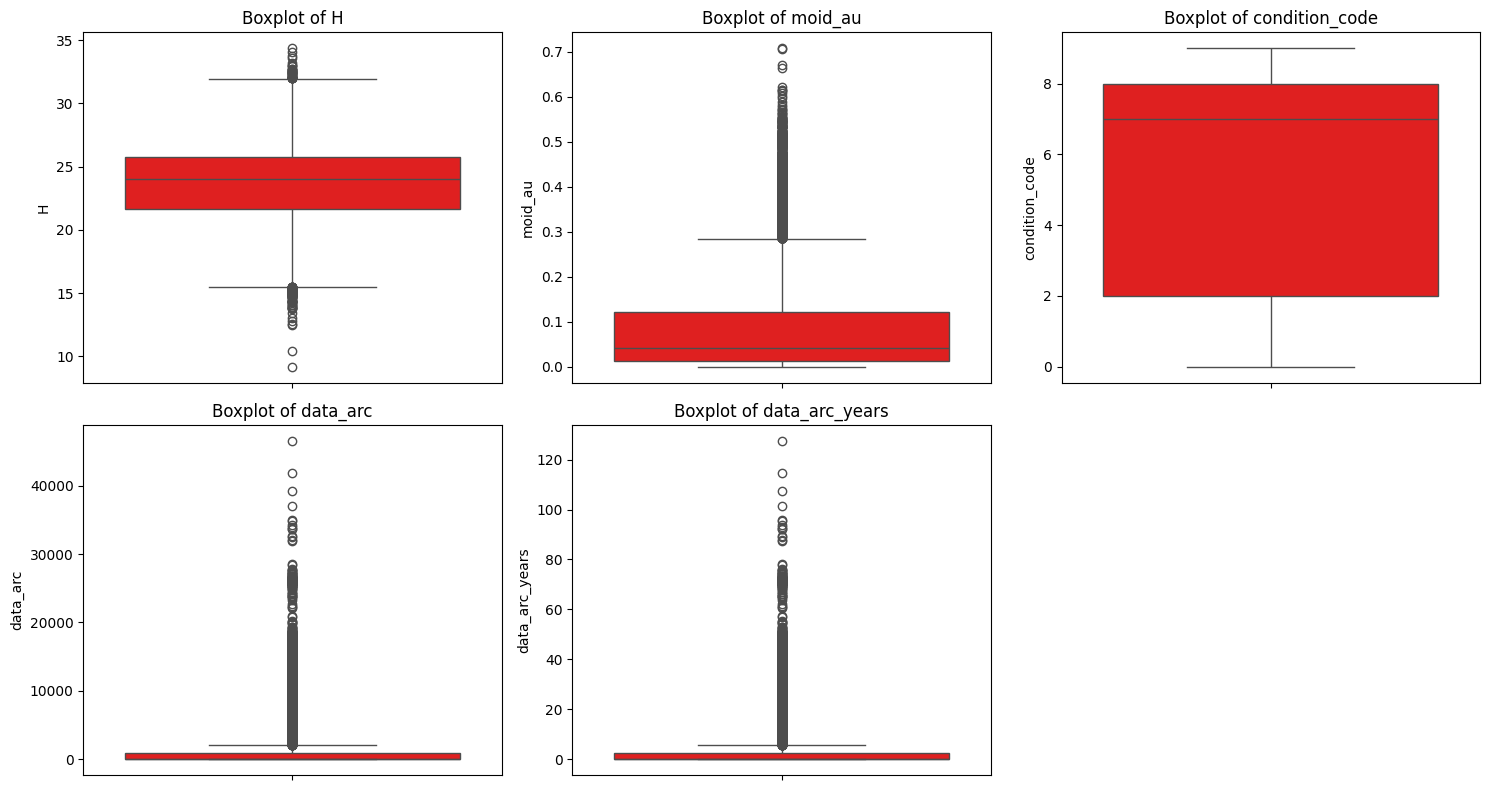

In [101]:
cols = ['H', 'moid_au', 'condition_code', 'data_arc', 'data_arc_years']

# Create figure
plt.figure(figsize=(15,8))

# Loop through columns
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y = df2[col], color = "red")
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [93]:
# df2['H'].fillna(df2['H'].median(), inplace=True)

In [94]:
# df2['moid_au'].fillna(df2['moid_au'].median(), inplace=True)

In [95]:
# df2['condition_code'].fillna(df2['condition_code'].median(), inplace=True)

In [96]:
# df2['data_arc'].fillna(df2['data_arc'].median(), inplace=True)

In [97]:
# df2['data_arc_years'].fillna(df2['data_arc_years'].median(), inplace=True)